Implement Resnet: https://arxiv.org/pdf/1512.03385.pdf

In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
    colab = True
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os

if os.name == 'nt':
    print("Disabling multiprocessing because we're running on windows.")
    cpu_num = 0
elif colab:
    cpu_num = 2
else:
    cpu_num = os.cpu_count() // 2
    print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.v2 as tv2
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/kyle/micromamba/envs/ml/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/kyle/micromamba/envs/ml/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedba

In [3]:
class ScaleToUnit(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x = x / 255.0
        return x

train_tfs = tvt.Compose([
    tv2.ToImageTensor(),
    tv2.ToDtype(torch.float32),
    ScaleToUnit(),
    tv2.RandomCrop(32, 4),
    tvt.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    tv2.RandomHorizontalFlip(0.5),
    tv2.RandomVerticalFlip(0.25),

])

val_tfs = tvt.Compose([
    tv2.ToImageTensor(),
    tv2.ToDtype(torch.float32),
    ScaleToUnit(),
])

# train_tfs = tvt.Compose([
#     tvt.RandomCrop(32, padding=4),
#     tvt.RandomHorizontalFlip(),
#     tvt.ToTensor(),
#     tvt.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
# ])

# val_tfs = tvt.Compose([
#     tvt.ToTensor(),
#     tvt.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
# ])

cifar_train = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=True,
    transform=train_tfs,
)
cifar_train = tds.wrap_dataset_for_transforms_v2(cifar_train)

cifar_eval = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=False,
    transform=val_tfs,
)
cifar_eval = tds.wrap_dataset_for_transforms_v2(cifar_eval)

Files already downloaded and verified
Files already downloaded and verified


tensor(0.4016)


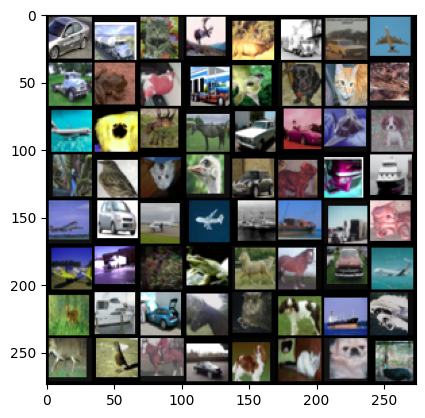

In [4]:
def random_grid(imgs, sz: int):
    grid = tu.make_grid(imgs)
    return grid.permute(1, 2, 0)

num=64
augmented = torch.stack([x[0] for x in random.choices(cifar_train, k=num)])
print(augmented.mean())
tmps = random_grid(augmented, num)
plt.imshow(tmps.cpu())
del augmented
del tmps

In [5]:
batchsize = 128

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [6]:
class ResUnit(nn.Module):
    def __init__(self, channels, downsample=False):
        super().__init__()
        channels_out = channels*2 if downsample else channels;
        layer1_stride = 2 if downsample else 1;

        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(channels, channels_out, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(channels_out)
        
        self.conv2 = nn.Conv2d(channels_out, channels_out, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(channels_out)

        if downsample:
            self.conv_d = nn.Conv2d(channels, channels_out, kernel_size=1, stride=1)
            self.bn_d = nn.BatchNorm2d(channels_out)

    def forward(self, x):
        xid = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        if self.downsample:
            xid = self.conv_d(xid)
            xid = self.relu(xid)
            xid = self.bn_d(xid)
        x += xid
        # Combine the feature maps before running the activation
        x = F.relu(x)
        if self.downsample:
            x = F.max_pool2d(x, kernel_size=2)
        
        return x

class ResNet(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.ch = ch
        self.out_sz = out_sz
        self.relu = nn.ReLU(inplace=True)

        # self.conv_i1 = nn.Conv2d(3, ch, kernel_size=7, stride=2, padding=3)
        # self.bn_i1 = nn.BatchNorm2d(ch)
        self.conv_i2 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.bn_i2 = nn.BatchNorm2d(ch)

        self.l1_1 = ResUnit(ch, False)
        self.l1_2 = ResUnit(ch, False)
        self.l1_3 = ResUnit(ch, True)
        
        self.l2_1 = ResUnit(ch*2, False)
        self.l2_2 = ResUnit(ch*2, False)
        self.l2_3 = ResUnit(ch*2, True)
        
        self.l3_1 = ResUnit(ch*4, False)
        self.l3_2 = ResUnit(ch*4, False)
        self.l3_3 = ResUnit(ch*4, True)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(ch*8, out_sz)
        
    def forward(self, x):
        # x = self.conv_i1(x)
        # x = self.relu(x)
        # x = self.bn_i1(x)

        x = self.conv_i2(x)
        x = self.relu(x)
        x = self.bn_i2(x)

        x = self.l1_1(x)
        x = self.l1_2(x)
        x = self.l1_3(x)
        
        x = self.l2_1(x)
        x = self.l2_2(x)
        x = self.l2_3(x)
        
        x = self.l3_1(x)
        x = self.l3_2(x)
        x = self.l3_3(x)

        x = self.avgpool(x)
        x = self.fc(x.view(-1, self.ch*8))
        
        return x

In [8]:
from torchinfo import summary
testmodel = ResNet(10, 64)
summary(testmodel, (1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,792
├─ReLU: 1-2                              [1, 64, 32, 32]           --
├─BatchNorm2d: 1-3                       [1, 64, 32, 32]           128
├─ResUnit: 1-4                           [1, 64, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           36,928
│    └─BatchNorm2d: 2-2                  [1, 64, 32, 32]           128
│    └─ReLU: 2-3                         [1, 64, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 64, 32, 32]           36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 32, 32]           128
├─ResUnit: 1-5                           [1, 64, 32, 32]           --
│    └─Conv2d: 2-6                       [1, 64, 32, 32]           36,928
│    └─BatchNorm2d: 2-7                  [1, 64, 32, 32]           

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 34.03it/s]


Epoch 0: 1.1216610670089722 
Current LR is [0.01]
5948/10000 correct, 59.48%


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 34.25it/s]


Epoch 1: 0.9360579252243042 
Current LR is [0.009999383162408303]
6711/10000 correct, 67.11%


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.67it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.74it/s]


Epoch 98: 0.32667312026023865 
Current LR is [0.005157053795390639]
9143/10000 correct, 91.43%


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.69it/s]


Epoch 99: 0.30457308888435364 
Current LR is [0.005078536586559101]
9158/10000 correct, 91.58%


 12%|███████████████▉                                                                                                                  | 48/391 [00:01<00:14, 24.07it/s]


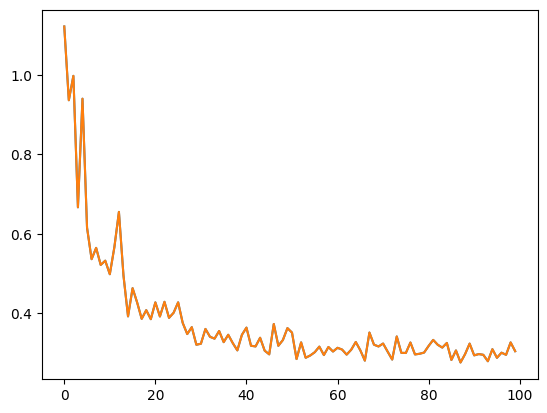

In [8]:
model = ResNet(out_sz=10, ch=64).to(device).train()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
epochs = 100
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

lossfn = nn.CrossEntropyLoss()
loss_plot = []
try:
    for epoch in range(epochs):
        model.train()
        for i, (images, target) in enumerate(tqdm(train_loader)):
            optimizer.zero_grad()
            images = images.to(device)
            targets = target.to(device)
    
            outs = model(images)
            loss = lossfn(outs, targets)
            loss.backward()
            optimizer.step()
    
        losses = []
        model.eval()
        correct = 0
        total = len(cifar_eval)
        for i, (images, target) in enumerate(val_loader):
            with torch.no_grad():
                images = images.to(device)
                targets = target.to(device)
                outs = model(images)
    
                loss = lossfn(outs, targets)
                losses.append(loss)
                for x in range(outs.shape[0]):
                    preds = F.softmax(outs, dim=1)
                    cls = preds[x].argmax()
                    lbl = targets[x]
                    if cls == lbl:
                        correct += 1
                    
        epoch_loss = torch.Tensor(losses).mean().item()
        print("Epoch {}: {} ".format(epoch, epoch_loss))
        print("Current LR is {}".format(scheduler.get_last_lr()))
        print("{}/{} correct, {:.2f}%".format(correct, total, 100*correct/total))
        loss_plot.append(epoch_loss)
        scheduler.step()
        
except KeyboardInterrupt:
    plt.plot(loss_plot)
plt.plot(loss_plot)

In [12]:
from ipywidgets import interact

classes = {
    0:  "Airplane",
    1: 	"Automobile",
    2: 	"Bird",
    3: 	"Cat",
    4: 	"Deer",
    5: 	"Dog",
    6: 	"Frog",
    7: 	"Horse",
    8: 	"Ship",
    9: 	"Truck",
}

@interact(index=(0, len(cifar_eval) - 1, 1))
def draw_preds(index=0):
    model.eval()
    with torch.no_grad():
        image = cifar_eval[index][0]
        pred = model(image.float().unsqueeze(0).to(device))
        pred = F.softmax(pred, dim=1)
        clsid = pred.argmax()
        plt.imshow(image.float().cpu().squeeze().permute(1, 2, 0), cmap='gray')
        print(classes[int(clsid)])

interactive(children=(IntSlider(value=0, description='index', max=9999), Output()), _dom_classes=('widget-inte…